# Acesso à Eletricidade e Desenvolvimento Econômico Global.

#### Contexto
Este conjunto de dados reúne indicadores do Banco Mundial ao longo de 25 anos, 
permitindo analisar a relação entre desenvolvimento econômico, dinâmica populacional 
e acesso à eletricidade em nível global.

Dataset inspirado no projeto de Muhammad Aammar Tufail, esta análise foi desevolvida com abordagem própria para fins de estudo.

## Perguntas respondidas neste notebook

### 1. Panorama Global do Acesso à Eletricidade
###### 1.1 - Quantos países tinham 100% de acesso à eletricidade (urbano e rural) em 2015?
###### 1.2 - Qual é a tendência média global de acesso à eletricidade rural (2000–2016)?
###### 1.3 - Quais países apresentam o crescimento mais rápido em eletricidade rural?
###### 1.4 - Quais países têm a maior disparidade entre o acesso à eletricidade urbana e rural?

### 2. Energia e Desenvolvimento Econômico
###### 2.1 - Os 10 principais países por PIB per capita em 2023?
###### 2.2 - Existe correlação entre PIB per capita e acesso à eletricidade?
###### 2.3 - Existe um nível de PIB a partir do qual o acesso tende a ser universal?

### 3. Demografia e Infraestrutura
###### 3.1 - Como a população global mudou (2000–2024)?
###### 3.2 - Como a produção de eletricidade se relaciona com a população?
###### 3.3 - Países com crescimento populacional alto conseguem expandir acesso?

# Análise Exploratória de Dados (EDA – Exploratory Data Analysis).


Importing Required Libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pycountry



# Paleta de cores para o projeto

cor_projeto = {
    "primary": "#1f4e79",
    "secondary": "#81E979",
    "accent": "#E0D8DE",
    "neutral": "#011502", 
    "highlight": "#FF686B"
}

Loading & Inspecting the Dataset


In [8]:
df = pd.read_csv('../data/global_electricity_access_economic_indicators.csv')

print(f'Dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas')

Dataset contém 7381 linhas e 9 colunas


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7381 entries, 0 to 7380
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              7381 non-null   str    
 1   date                                 7381 non-null   int64  
 2   GDP_Per_Capita_Current_USD           6433 non-null   float64
 3   Total_Population                     6625 non-null   float64
 4   Population_Female_Percentage         6625 non-null   float64
 5   Population_Male_Percentage           6625 non-null   float64
 6   Electricity_Access_Urban_Percentage  3675 non-null   float64
 7   Electricity_Access_Rural_Percentage  3376 non-null   float64
 8   Total_Electricity_Output_GWh         3647 non-null   float64
dtypes: float64(7), int64(1), str(1)
memory usage: 519.1 KB


Podemos verificar que temos um valor considerável de itens em branco

In [10]:
df.describe().round(2)

,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
count,7381.00,6433.00,6.625000e+03,6625.00,6625.00,3675.00,3376.00,3647.00
mean,2011.60,14909.43,2.886783e+08,50.05,49.95,88.76,72.85,86963.55
std,7.12,23577.55,9.013583e+08,2.61,2.61,20.50,36.00,395737.76
min,2000.00,109.59,9.544000e+03,23.82,45.05,0.00,0.01,0.00
25%,2005.00,1563.11,1.463495e+06,49.57,48.94,87.97,42.39,395.50
50%,2011.00,5126.05,9.745953e+06,50.30,49.70,99.55,95.90,4980.00
75%,2018.00,18780.13,6.000225e+07,51.06,50.43,100.00,100.00,36399.00
max,2024.00,288001.43,8.141809e+09,54.95,76.18,100.00,100.00,5844158.00


In [11]:
df.head(5)

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [12]:
df.tail(5)

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
7376,Zimbabwe,2020,2059.674454,15526888.0,52.530169,47.469831,NaN,NaN,NaN
7377,Zimbabwe,2021,2613.605421,15797210.0,52.488560,47.511440,NaN,NaN,NaN
7378,Zimbabwe,2022,2536.400502,16069056.0,52.438295,47.561705,NaN,NaN,NaN
7379,Zimbabwe,2023,2195.224921,16340822.0,52.383460,47.616540,NaN,NaN,NaN
7380,Zimbabwe,2024,2497.203322,16634373.0,52.333109,47.666891,NaN,NaN,NaN


In [13]:
df.isnull().sum().sort_values(ascending=False)

Electricity_Access_Rural_Percentage    4005
Total_Electricity_Output_GWh           3734
Electricity_Access_Urban_Percentage    3706
GDP_Per_Capita_Current_USD              948
Total_Population                        756
Population_Male_Percentage              756
Population_Female_Percentage            756
country                                   0
date                                      0
dtype: int64

In [14]:
percentual_nulos = (df.isnull().sum() / len(df)) * 100
percentual_nulos.sort_values(ascending=False).round(2)


Electricity_Access_Rural_Percentage    54.26
Total_Electricity_Output_GWh           50.59
Electricity_Access_Urban_Percentage    50.21
GDP_Per_Capita_Current_USD             12.84
Total_Population                       10.24
Population_Male_Percentage             10.24
Population_Female_Percentage           10.24
country                                 0.00
date                                    0.00
dtype: float64

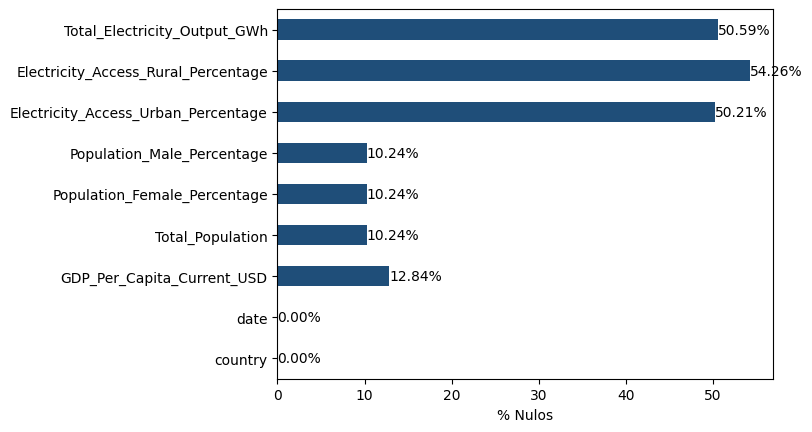

In [15]:
ax = percentual_nulos.plot(kind='barh', color=cor_projeto["primary"], xlabel='% Nulos')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

# Transformando em DataFrame para melhor visualização, pois nem todas as informações da coluna de países são de fato países
pd.DataFrame(sorted(df['country'].unique()), columns=['country'])

plt.show()

In [16]:
# Transformando em DataFrame para melhor visualização, pois nem todas as informações da coluna de países são de fato países
pd.DataFrame(sorted(df['country'].unique()), columns=['country'])

,country
0,Afghanistan
1,Africa Eastern and Southern
2,Africa Western and Central
3,Albania
4,Algeria
...,...
304,Western Sahara
305,World
306,"Yemen, Rep."
307,Zambia


In [17]:
# Realizando a correção de alguns países

paises_correcoes = {'Cape Verde': 'Cabo Verde',
    'Czech Republic': 'Czechia',
    'Swaziland': 'Eswatini',
    'Turkey': 'Turkiye',
    'Vietnam': 'Viet Nam',
    'Somalia, Fed. Rep.': 'Somalia',
    "Korea, Dem. People's Rep.": "Korea, Dem. Rep."}

df['country'] = df['country'].replace(paises_correcoes)

print(f'Valores únicos {len(df['country'].unique())}')

Valores únicos 302


In [18]:
# Para cada país dentro da lista oficial de países pegue apenas o nome
paises_oficiais = {country.name for country in pycountry.countries}

df_paises = df[df["country"].isin(paises_oficiais)].copy()

print(f'O número de países reconhecidos e válidos é de {len(df_paises['country'].unique())}')

O número de países reconhecidos e válidos é de 195


Seguiremos nossas análises baseadas nesses 195 países

In [19]:
df_paises.info()

<class 'pandas.DataFrame'>
Index: 4880 entries, 0 to 7380
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              4880 non-null   str    
 1   date                                 4880 non-null   int64  
 2   GDP_Per_Capita_Current_USD           4524 non-null   float64
 3   Total_Population                     4625 non-null   float64
 4   Population_Female_Percentage         4625 non-null   float64
 5   Population_Male_Percentage           4625 non-null   float64
 6   Electricity_Access_Urban_Percentage  3131 non-null   float64
 7   Electricity_Access_Rural_Percentage  2916 non-null   float64
 8   Total_Electricity_Output_GWh         3026 non-null   float64
dtypes: float64(7), int64(1), str(1)
memory usage: 381.2 KB


In [20]:
print(f'O maior ano é : {df_paises['date'].max()}, e o menor ano é: {df_paises['date'].min()} e temos nosso Dataset com {df_paises.shape[0]} linhas e {df_paises.shape[1]} colunas.')

O maior ano é : 2024, e o menor ano é: 2000 e temos nosso Dataset com 4880 linhas e 9 colunas.


# Desenvolvimento das questões e Insights

### 1. Panorama Global do Acesso à Eletricidade


##### 1.1 - Quantos países tinham 100% de acesso à eletricidade (urbano e rural) em 2015?

In [21]:
df_paises.head(5)

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [22]:
# Filtrando os países com 100% de acesso a energia
df_paises_primeira_questao = df_paises.loc[(df_paises['date']== 2015) & (df['Electricity_Access_Urban_Percentage']==100) & (df['Electricity_Access_Rural_Percentage']==100)]

In [23]:
pd.DataFrame(sorted(df_paises_primeira_questao['country'].unique()), columns=['paises'])

,paises
0,Albania
1,Andorra
2,Armenia
3,Australia
4,Austria
...,...
64,United Arab Emirates
65,United Kingdom
66,United States
67,Uzbekistan


In [24]:
print(f' {len(df_paises_primeira_questao['country'].unique())} países tem a parte urbana e rural com acesso a 100% de energia em 2015')

 69 países tem a parte urbana e rural com acesso a 100% de energia em 2015


##### 1.2 - Qual é a tendência média global de acesso à eletricidade rural (2000–2016)?

In [25]:
df_paises.head(5)

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


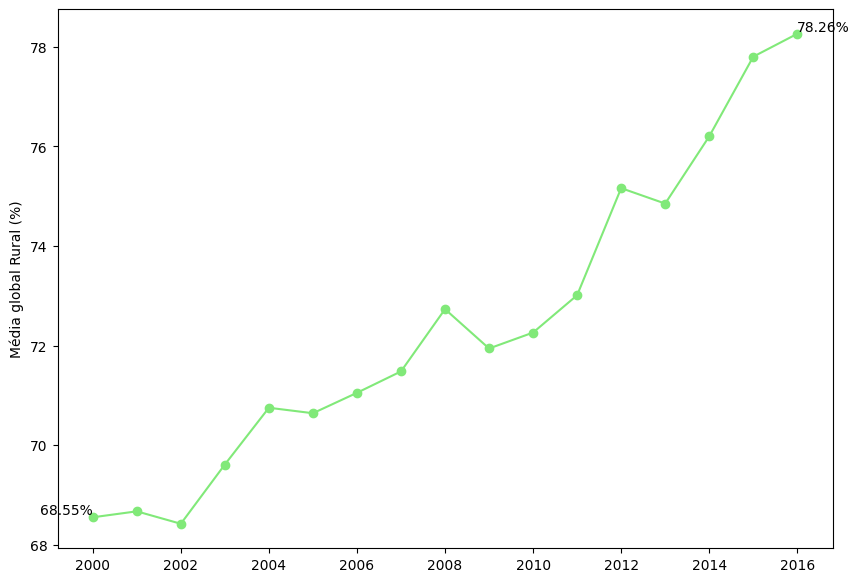

In [26]:
df_segunda_questao = df_paises.loc[(df['date'].between(2000,2016))]
df_segunda_questao = df_segunda_questao.groupby('date')['Electricity_Access_Rural_Percentage'].mean().round(2)

ax = df_segunda_questao.plot(kind='line',
                        color=cor_projeto['secondary'],
                        marker='o',
                        xlabel='',
                        ylabel='Média global Rural (%)',
                        figsize=[10,7])

# Primeiro ponto
x_inicio = df_segunda_questao.index[0]
y_inicio = df_segunda_questao.iloc[0]

# Último ponto
x_fim = df_segunda_questao.index[-1]
y_fim = df_segunda_questao.iloc[-1]

# Adicionar rótulos
ax.text(x_inicio, y_inicio, f'{y_inicio:.2f}%', 
        ha='right', va='bottom')

ax.text(x_fim, y_fim, f'{y_fim:.2f}%', 
        ha='left', va='bottom')


plt.show()

Entre 2000 e 2016, observa-se uma tendência claramente crescente no acesso médio global à eletricidade em áreas rurais. O indicador evoluiu de aproximadamente 68,63% em 2000 para 78,77% em 2016, representando um aumento de cerca de 10,14 pontos percentuais no período.

O crescimento foi relativamente consistente ao longo dos anos, com pequenas oscilações pontuais. Destaca-se uma aceleração mais evidente após 2011, sugerindo possíveis avanços em políticas públicas, investimentos em infraestrutura elétrica rural e expansão de programas de eletrificação em países em desenvolvimento.

Em 2008, observa-se um aumento mais acentuado em relação aos anos anteriores. É interessante que seja feito um trabalho de aprofundar a análise por país para identificar a causa específica.

##### 1.3 - Quais países apresentam o crescimento mais rápido em eletricidade rural?


In [27]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


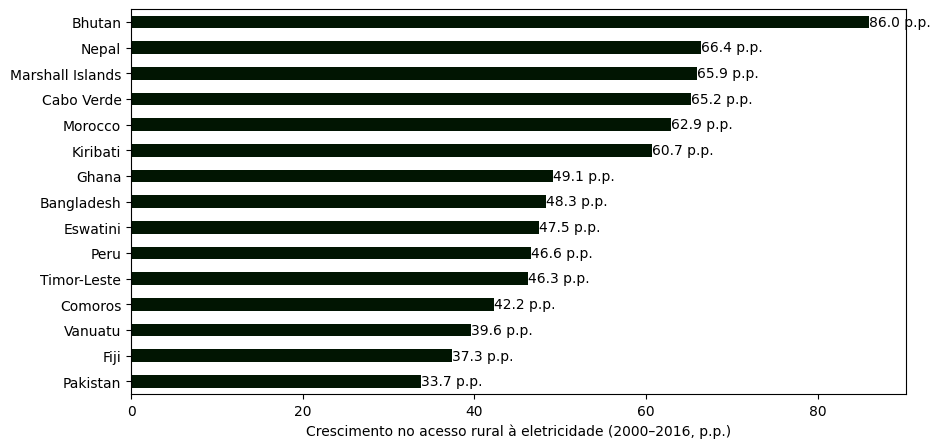

In [28]:
df_terceira_questao = df_paises[(df_paises['Electricity_Access_Rural_Percentage'].notna()) & (df_paises['date'].isin([2000,2016]))]

df_terceira_questao = pd.pivot_table(data=df_terceira_questao, index=['date'],columns=['country'], values= 'Electricity_Access_Rural_Percentage')

df_terceira_questao = df_terceira_questao.dropna(axis=1)

df_terceira_questao = df_terceira_questao.loc[2016] - df_terceira_questao.loc[2000]
df_terceira_questao = df_terceira_questao.sort_values(ascending=False)

df_terceira_questao_top15 = df_terceira_questao.nlargest(15).sort_values(ascending=True)

ax = df_terceira_questao_top15.plot(kind='barh',
                                    figsize=[10,5],
                                    ylabel='',
                                    color=cor_projeto['neutral'],
                                    xlabel='Crescimento no acesso rural à eletricidade (2000–2016, p.p.)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f p.p.')



Entre 2000 e 2016, os maiores crescimentos no acesso rural à eletricidade ocorreram majoritariamente em países em desenvolvimento, com destaque para Bhutan (+86 p.p.), Nepal (+66,4 p.p.) e Marshall Islands (+65,9 p.p.). Observa-se concentração de países africanos e do Sul da Ásia entre os maiores avanços, sugerindo forte expansão de infraestrutura elétrica em economias que partiam de níveis historicamente baixos de acesso rural.

##### 1.4 - Quais países têm a maior disparidade entre o acesso à eletricidade urbana e rural?

In [29]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


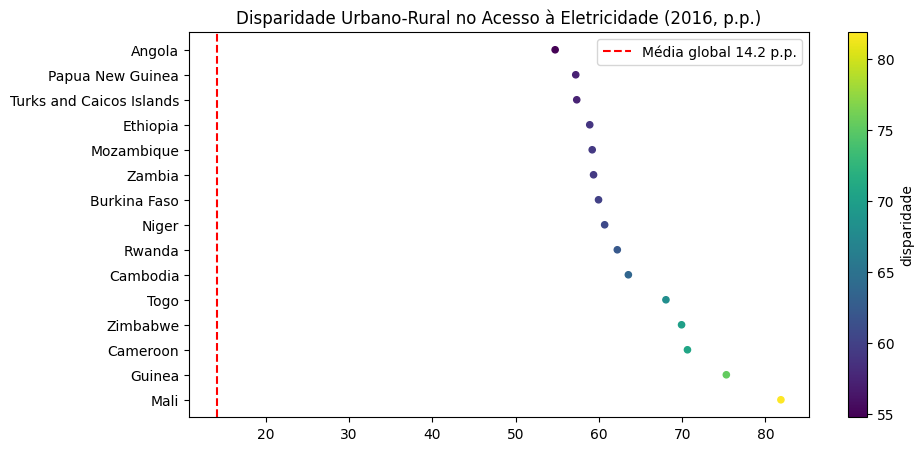

In [30]:
df_quarta_questao = df_paises.loc[(df_paises['date']==2016)].copy()
df_quarta_questao['disparidade'] = (df_quarta_questao['Electricity_Access_Urban_Percentage'] - df_quarta_questao['Electricity_Access_Rural_Percentage'])
df_quarta_questao_top15 = df_quarta_questao.sort_values('disparidade', ascending=False).head(15)
media_disparidade = df_quarta_questao['disparidade'].mean()


df_quarta_questao_top15.plot.scatter(x='disparidade',y='country', c='disparidade', figsize=[10,5])
plt.axvline(media_disparidade, color='red', linestyle='--', label=f'Média global {media_disparidade:.1f} p.p.')
plt.legend()
plt.title('Disparidade Urbano-Rural no Acesso à Eletricidade (2016, p.p.)')
plt.xlabel('')
plt.ylabel('')
plt.show()

A média global da disparidade urbano-rural em 2016 foi de aproximadamente 14,2 pontos percentuais. No entanto, os países com maior desigualdade apresentam diferenças superiores a 50 p.p., evidenciando forte concentração da infraestrutura elétrica nas áreas urbanas e significativo atraso nas regiões rurais. Como Mali, Guinea e Cameroon.

### 2. Energia e Desenvolvimento Econômico

##### 2.1 - Os 10 principais países por PIB per capita em 2023?

In [31]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [32]:
df_principais_pib = df_paises.loc[df_paises['date']==2023].copy().sort_values('GDP_Per_Capita_Current_USD', ascending=False)

In [33]:
df_principais_pib = df_paises.loc[df_paises['date']==2023].copy().sort_values('GDP_Per_Capita_Current_USD', ascending=False)

top10_pib = df_principais_pib.nlargest(10, 'GDP_Per_Capita_Current_USD').reset_index(drop=True)

top10_pib = top10_pib.drop(columns=[ 'date', 'Total_Population',
       'Population_Female_Percentage', 'Population_Male_Percentage',
       'Electricity_Access_Urban_Percentage',
       'Electricity_Access_Rural_Percentage', 'Total_Electricity_Output_GWh'])

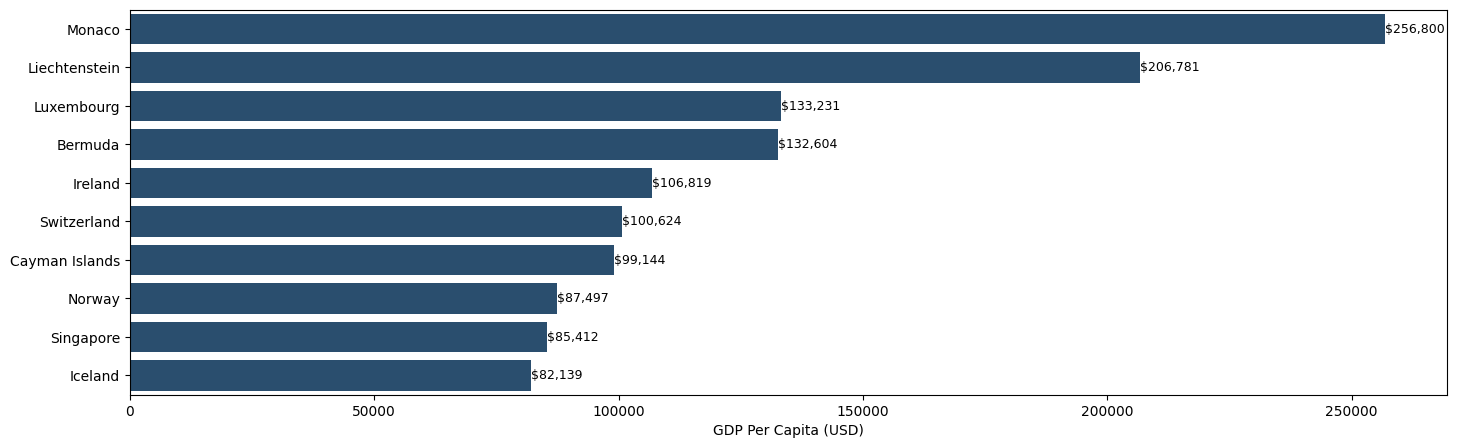

In [34]:
plt.figure(figsize=(17,5))

ax = sns.barplot(data=top10_pib,x=top10_pib['GDP_Per_Capita_Current_USD'], y='country', color=cor_projeto['primary'])
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('')

for container in ax.containers:
    labels = [f'${v:,.0f}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=9)


plt.show()

Os países com maior PIB per capita em 2023 concentram-se majoritariamente na Europa Ocidental e em centros financeiros globais. Esses países apresentam alta renda média e, consequentemente, espera-se que possuam infraestrutura energética universalizada e baixos níveis de disparidade no acesso à eletricidade.

##### 2.2 - Existe correlação entre PIB per capita e acesso à eletricidade?


In [35]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [36]:
df_corr = df_paises.groupby('country').agg({
    'GDP_Per_Capita_Current_USD': 'mean',
    'Electricity_Access_Rural_Percentage': 'mean',
    'Electricity_Access_Urban_Percentage': 'mean'
}).dropna().round(2)

In [37]:
df_corr_final = df_corr.corr().copy()

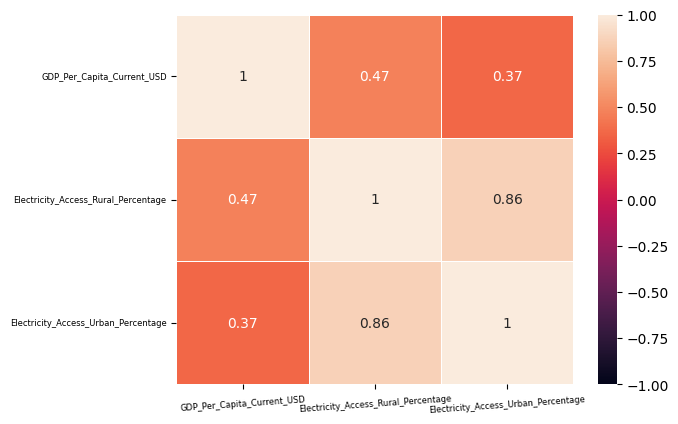

<Figure size 2000x2000 with 0 Axes>

In [38]:
sns.heatmap(data=df_corr_final, annot=True, vmin=-1, vmax=1, linewidths=0.5)
plt.xticks(rotation=4, fontsize=6)
plt.yticks(fontsize=6)
plt.figure(figsize=[20,20])
plt.show()

Observa-se correlação positiva moderada entre PIB per capita médio e acesso rural à eletricidade (r=0.47), sugerindo que países mais ricos tendem a apresentar melhor cobertura rural.

Já a relação entre PIB e acesso urbano é mais fraca (r=0.37), possivelmente devido ao fato de que a eletrificação urbana já se encontra em níveis elevados na maioria dos países, independentemente do nível de renda.

##### 2.3 - Existe um nível de PIB a partir do qual o acesso tende a ser universal?


In [39]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [40]:
df_pib_universal = df_paises.copy()

df_pib_universal['Universal'] = (
    (df_paises['Electricity_Access_Urban_Percentage'] == 100) &
    (df_paises['Electricity_Access_Rural_Percentage'] == 100)
)

In [41]:
df_pib_universal = (
    df_pib_universal[df_pib_universal['Universal']]
    .groupby('date')['GDP_Per_Capita_Current_USD']
    .min()
)

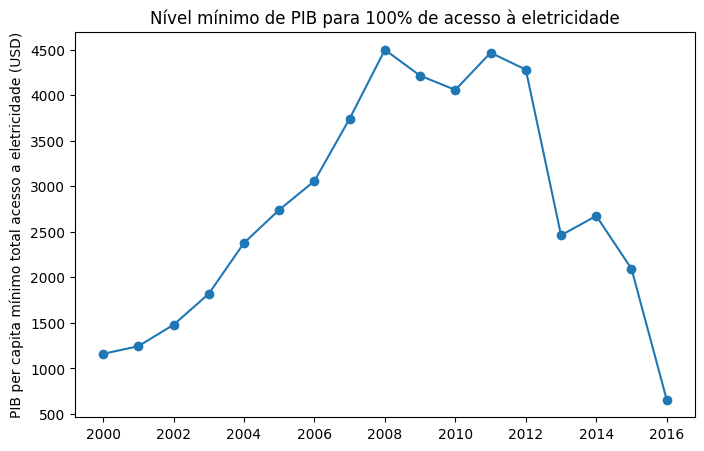

In [42]:
plt.figure(figsize=(8,5))

df_pib_universal.plot(marker='o')

plt.ylabel('PIB per capita mínimo total acesso a eletricidade (USD)')
plt.title('Nível mínimo de PIB para 100% de acesso à eletricidade')
plt.xlabel('')
plt.show()

A evolução do PIB mínimo entre países com acesso universal não segue um padrão linear. No início dos anos 2000, observa-se que alguns países com renda per capita relativamente baixa já apresentavam universalização. Entre 2006 e 2012, o nível mínimo de renda entre países universalizados aumentou significativamente, concentrando-se em economias de renda média. No entanto, a partir de 2013 verifica-se nova redução desse valor, indicando que países com menor nível de renda passaram a atingir acesso universal, possivelmente impulsionados por avanços tecnológicos e políticas públicas direcionadas.

### 3. Demografia e Infraestrutura

##### 3.1 - Como a população global mudou (2000–2024)?

In [43]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [44]:
df_populacao = df_paises.copy()

In [45]:
df_populacao = (
    df_populacao[df_populacao["Total_Population"].notna()]
    .groupby("date")["Total_Population"]
    .sum()
    .reset_index()
)

df_populacao = df_populacao.sort_values('date')

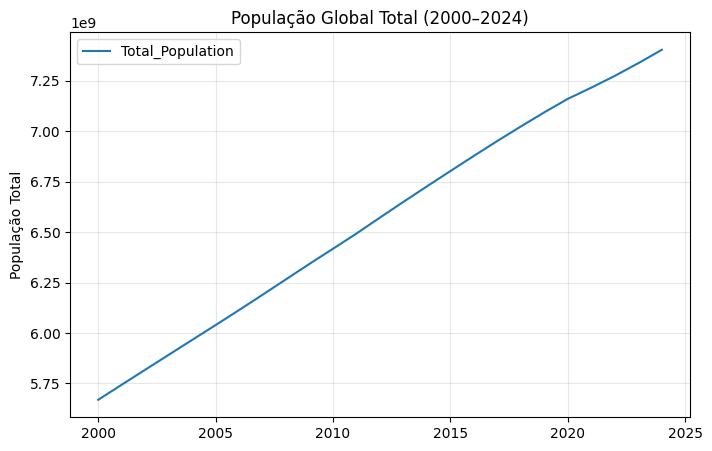

In [46]:
df_populacao.plot(
    kind='line',
    x='date',
    y='Total_Population',
    figsize=(8,5),
)

plt.title('População Global Total (2000–2024)')
plt.xlabel('')
plt.ylabel('População Total')
plt.grid(alpha=0.3)


plt.show()

Entre 2000 e 2024, a população global cresceu de aproximadamente 5,7 bilhões para 7,4 bilhões de pessoas, representando um aumento de cerca de 1,7 bilhão no período. O crescimento ocorreu de forma contínua e relativamente estável.

##### 3.2 - Como a produção de eletricidade se relaciona com a população?

In [47]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [48]:
df_relacao = df_paises.groupby('country').agg({
    'Total_Population': 'mean',
    'Total_Electricity_Output_GWh': 'mean'
}).dropna()

In [49]:
df_relacao.head()

,Total_Population,Total_Electricity_Output_GWh
country,,
Afghanistan,30918068.20,895.456250
Albania,2795636.96,4983.250000
Algeria,38159793.84,42054.062500
American Samoa,53469.72,173.630375
Andorra,76014.84,90.087500


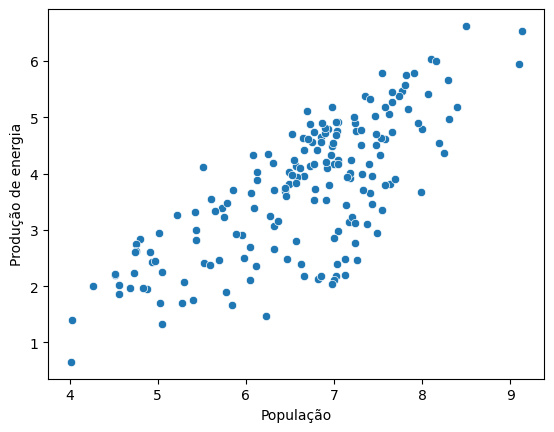

In [50]:
df_relacao['log_pop'] = np.log10(df_relacao['Total_Population'])
df_relacao['log_energy'] = np.log10(df_relacao['Total_Electricity_Output_GWh'])

sns.scatterplot(data=df_relacao, x='log_pop', y='log_energy')
plt.xlabel('População')
plt.ylabel('Produção de energia')
plt.show()

Observa-se uma correlação positiva entre população e produção de eletricidade. Países mais populosos tendem a produzir maior volume absoluto de energia. A aplicação da escala logarítmica revela um padrão aproximadamente linear, indicando uma relação estrutural consistente entre tamanho populacional e demanda energética.

##### 3.3 - Países com crescimento populacional alto conseguem expandir acesso rural?

In [51]:
df_paises.head()

,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [52]:
df_crescimento = df_paises[df_paises['date'].isin([2000, 2016])]

df_populacao_agg = df_crescimento.pivot_table(
    index='country',
    columns='date',
    values='Total_Population'
).dropna()

df_populacao_agg['Crescentimento_%'] = (
    (df_populacao_agg[2016] - df_populacao_agg[2000]) / df_populacao_agg[2000]
) * 100

In [53]:
df_populacao_agg

date,2000,2016,Crescentimento_%
country,,,
Afghanistan,20130327.0,34700612.0,72.379773
Albania,3089027.0,2689469.0,-12.934753
Algeria,30903893.0,40850721.0,32.186327
American Samoa,56855.0,52245.0,-8.108346
Andorra,65685.0,72181.0,9.889625
...,...,...,...
Uzbekistan,24787054.0,31284568.0,26.213337
Vanuatu,186281.0,272087.0,46.062669
Viet Nam,77154011.0,94000117.0,21.834388


In [54]:
df_cresciento_energia = df_crescimento.pivot_table(
    index='country',
    columns='date',
    values='Electricity_Access_Rural_Percentage'
).dropna()

df_cresciento_energia['Crescimento_Energia_%'] = (
    df_cresciento_energia[2016] - df_cresciento_energia[2000]
)

In [55]:
df_cresciento_energia

date,2000,2016,Crescimento_Energia_%
country,,,
Albania,100.000000,100.000000,0.000000
Algeria,97.570247,98.955372,1.385125
Andorra,100.000000,100.000000,0.000000
Angola,14.098354,15.984209,1.885855
Antigua and Barbuda,85.372811,96.546891,11.174080
...,...,...,...
Uzbekistan,99.487242,100.000000,0.512758
Vanuatu,6.849902,46.440000,39.590098
Viet Nam,82.133666,100.000000,17.866334


In [56]:
df_analise = df_populacao_agg[['Crescentimento_%']].join(
    df_cresciento_energia[['Crescimento_Energia_%']],
    how='inner'
)

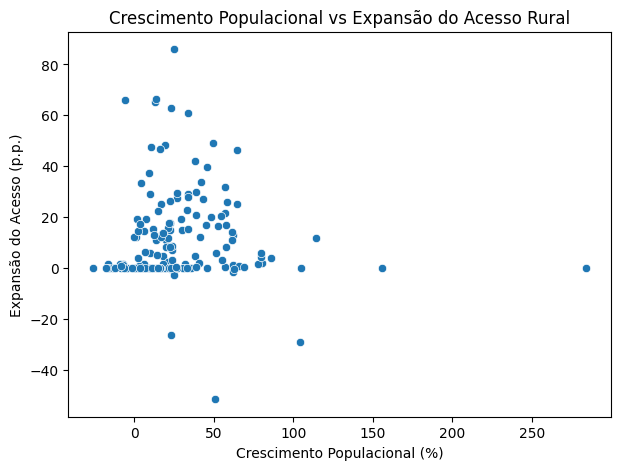

In [57]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_analise,
    x='Crescentimento_%',
    y='Crescimento_Energia_%'
)

plt.title("Crescimento Populacional vs Expansão do Acesso Rural")
plt.xlabel("Crescimento Populacional (%)")
plt.ylabel("Expansão do Acesso (p.p.)")

plt.show()

Não dá para dizer que países que crescem mais em população conseguem automaticamente expandir o acesso à eletricidade rural. Os resultados variam bastante, mostrando que o crescimento demográfico por si só não explica a evolução do acesso.